# Molecular Data Processing Pipeline

This notebook contains functions for processing molecular data, particularly for genomic and mutation analysis.

## Imports

In [13]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
import mygene
from sklearn.preprocessing import MultiLabelBinarizer

## Chromosome Processing Functions

In [2]:
def to_int(chromosome_str):
    """
    Convert chromosome identifier to integer.
    
    Parameters:
    -----------
    chromosome_str : str
        Chromosome identifier (e.g., '1', '2', 'X')
        
    Returns:
    --------
    int
        Integer representation of chromosome (X is converted to 23)
        
    Raises:
    -------
    ValueError
        If input is not a string or cannot be converted to integer
    """
    if not isinstance(chromosome_str, str):
        raise ValueError("Input must be a string")
        
    if chromosome_str.upper() == 'X':
        return 23  # X chromosome is represented as 23
    else:
        try:
            return int(chromosome_str)
        except ValueError:
            raise ValueError(f"Cannot convert '{chromosome_str}' to integer")


def chr_to_int(df, column_name="CHR"):
    """
    Convert chromosome identifiers in a dataframe column to integers.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing chromosome data
    column_name : str, default="CHR"
        Column name containing chromosome identifiers

    Returns:
    --------
    pl.DataFrame
        DataFrame with chromosome identifiers converted to integers

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    try:
        df = df.with_columns(
            pl.col(column_name).map_elements(to_int, return_dtype=pl.Int64)
            .alias(column_name)
        )
        return df
    except Exception as e:
        raise ValueError(f"Error converting chromosome to integer: {str(e)}")

## DNA Sequence Processing Functions

In [3]:
def dna_to_array(dna_sequence):
    """
    Convert DNA sequence to array of nucleotides, replacing non-standard bases with 'n'.

    Parameters:
    -----------
    dna_sequence : str
        DNA sequence string

    Returns:
    --------
    list
        List of nucleotides ('a', 'g', 't', 'c', or 'n')
    """
    if not isinstance(dna_sequence, str):
        raise ValueError("DNA sequence must be a string")

    nitrogen_bases = ['a', 'g', 't', 'c']
    dna_sequence = dna_sequence.lower()

    return [ch if ch in nitrogen_bases else 'n' for ch in dna_sequence]


def ordinal_encoder_dna(dna_sequence):
    """
    Encode DNA sequence as numerical values.

    Parameters:
    -----------
    dna_sequence : str or list
        DNA sequence as string or list of nucleotides

    Returns:
    --------
    list
        List of numerical values (a=0.25, c=0.5, g=0.75, t=1.0, other=0.0)
    """
    if isinstance(dna_sequence, str):
        dna_sequence = dna_to_array(dna_sequence)

    mapping = {'a': 0.25, 'c': 0.5, 'g': 0.75, 't': 1.00}

    return [mapping.get(x, 0.0) for x in dna_sequence]


def extract_kmers(sequence, k):
    """
    Extract k-mers from a sequence.

    Parameters:
    -----------
    sequence : str
        Input sequence
    k : int
        Length of k-mers

    Returns:
    --------
    list
        List of k-mers

    Raises:
    -------
    ValueError
        If k is larger than sequence length or not a positive integer
    """
    if not isinstance(sequence, str):
        raise ValueError("Sequence must be a string")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer")

    if k > len(sequence):
        raise ValueError(f"k ({k}) cannot be larger than sequence length ({len(sequence)})")

    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]


def join_str(str):
    return ' '.join(str)

## Gene and Protein Processing Functions

In [4]:
def gene_new_name(df, column_name):
    """
    Update gene names to their current nomenclature.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing gene names
    column_name : str
        Column name containing gene identifiers

    Returns:
    --------
    pl.DataFrame
        DataFrame with updated gene names

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")


    # Mapping of old gene names to current nomenclature
    mapping = {
        'MLL': 'KMT2A',      # Mixed-lineage leukemia -> Lysine methyltransferase 2A
        'WHSC1': 'NSD2',     # Wolf-Hirschhorn syndrome candidate 1 -> Nuclear SET domain-containing protein 2
        'H3F3A': 'H3-3A',    # H3 histone family member 3A -> Histone H3.3
        'FAM175A': 'ABRAXAS1', # Family with sequence similarity 175 member A -> BRCA1-A complex subunit Abraxas 1
        'PAPD5': 'TENT4B'    # PAP associated domain containing 5 -> Terminal nucleotidyltransferase 4B
    }

    try:
        df = df.with_columns(
            pl.col(column_name).map_elements(lambda g: mapping.get(g, g)).alias(column_name)
        )
        return df
    except Exception as e:
        raise ValueError(f"Error updating gene names: {str(e)}")

## Gene Ontology Functions

In [5]:
def cytogenetics(df, column_name):
    """
    Retrieve gene ontology information for genes in the dataframe.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing gene names
    column_name : str
        Column name containing gene identifiers

    Returns:
    --------
    list
        List of gene ontology results

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    genes = list(df[column_name].unique())

    try:
        mg = mygene.MyGeneInfo()
        results = mg.querymany(genes, scopes="symbol", fields='go', species="human", timeout=30)
        return results
    except Exception as e:
        print(f"Warning: Failed to retrieve gene ontology data: {e}")
        return []


def genes_to_go(results_cyto):
    """
    Extract gene ontology terms from mygene results.

    Parameters:
    -----------
    results_cyto : list
        List of gene ontology results from mygene

    Returns:
    --------
    dict
        Dictionary mapping gene symbols to GO term IDs
    """
    if not results_cyto:
        return {}

    gene_to_go = {}
    for res in results_cyto:
        gene = res.get('query')
        go_bp = res.get('go', {}).get('BP', [])

        # Handle case where go_bp is a dictionary (single term)
        if isinstance(go_bp, dict):
            go_bp = [go_bp]

        go_terms = [go['id'] for go in go_bp if 'id' in go]

        if gene and go_terms:
            gene_to_go[gene] = go_terms

    return gene_to_go


def multi_label_gene_go(gene_to_go, min_gene_count=5):
    """
    Create a binary matrix of genes and GO terms.

    Parameters:
    -----------
    gene_to_go : dict
        Dictionary mapping gene symbols to GO term IDs
    min_gene_count : int, default=5
        Minimum number of genes required for a GO term to be included

    Returns:
    --------
    pd.DataFrame
        Binary matrix with genes as index and GO terms as columns
    """
    if not gene_to_go:
        return pd.DataFrame()

    # Create binary matrix
    mlb = MultiLabelBinarizer()
    go_matrix = mlb.fit_transform(gene_to_go.values())
    go_df = pd.DataFrame(go_matrix, index=gene_to_go.keys(), columns=mlb.classes_)

    # Filter GO terms by frequency
    filtered_go_df = go_df.loc[:, (go_df.sum(axis=0) >= min_gene_count)]

    return filtered_go_df


def merge_df(df, filtered_go_df, join_column, join_type="left"):
    """
    Merge dataframe with GO terms dataframe.

    Parameters:
    -----------
    df : pl.DataFrame
        Main dataframe
    filtered_go_df : pd.DataFrame
        DataFrame with GO terms
    join_column : str
        Column name to join on
    join_type : str, default="left"
        Type of join to perform

    Returns:
    --------
    pl.DataFrame
        Merged dataframe

    Raises:
    -------
    ValueError
        If input dataframes are invalid or join column doesn't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("First dataframe must be a Polars DataFrame")

    if not isinstance(filtered_go_df, pd.DataFrame):
        raise ValueError("Second dataframe must be a Pandas DataFrame")

    if join_column not in df.columns:
        raise ValueError(f"Join column '{join_column}' not found in first DataFrame")

    if filtered_go_df.empty:
        return df

    try:
        # Convert to pandas for merge
        df_pd = df.to_pandas()

        # Merge dataframes
        df_merged = df_pd.merge(filtered_go_df, left_on=join_column, right_index=True, how=join_type)

        # Convert back to polars
        return pl.from_pandas(df_merged)
    except Exception as e:
        raise ValueError(f"Error merging dataframes: {str(e)}")

## Protein Analysis Functions

In [6]:
def protein_name(protein_changes, ch):
    lst_prot = []
    pattern = rf"p\.{ch}\d+.*"

    for prot in protein_changes:
        if isinstance(prot, str): 
            prot_name = re.findall(pattern, prot)
            if prot_name:
                lst_prot+=prot_name
                
    return lst_prot


def get_protein_dico(uppercase_alphabet, lst, aa_fullname):
    dico_protein_changes = {}
        
    for ch in uppercase_alphabet:
        if(len(lst) >=1):
            ch_name = aa_fullname.get(ch)
            dico_protein_changes[ch_name] = lst
            
    return dico_protein_changes


def protein_type(df, protein_change, dico_protein_changes):
    acide_aminee = {}

    for elem in protein_change:
        for aa_name, mutations in dico_protein_changes.items():
            if elem in mutations:
                acide_aminee[elem] = aa_name
                
                          
    # KMT2A => MLL PTD => Lysine 
    # FLT3-ID => FLT3 => tyrosine

    acide_aminee["MLL_PTD"] = "Lysine"
    acide_aminee["FLT3_ITD"] = "Tyrosine"
    acide_aminee["p.?"] = "Unknown"
    
    df = df.with_columns(
        pl.col("PROTEIN_CHANGE").map_elements(lambda x: acide_aminee.get(x, None)).alias("AA_TYPE")
    )
                
    return acide_aminee, df

## Mutation Analysis Functions

In [7]:
def is_protein_unknown(df):
    df = df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE") == "p.?")
        .then(1)
        .otherwise(0)
        .alias("IS_PT_UKNOWN")
    )
    
    return df

def is_frameshift(df):
    df = df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE").str.contains('fs'))
        .then(1)
        .otherwise(0)
        .alias("is_frameshift")
    )
    
    return df

def is_non_sens(df):
    #NON_SENS_MUTATION
    df = df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE").str.contains("\\*"))
        .then(1)
        .otherwise(0)
        .alias("is_non_sens_mutation")
    )
    
    return df


def is_missense(protein_change):
    """
    Check if a protein change is a missense mutation.

    Parameters:
    -----------
    protein_change : str
        Protein change annotation

    Returns:
    --------
    int
        1 if missense mutation, 0 otherwise
    """
    if protein_change is not None and isinstance(protein_change, str):
        # Check if it's a missense mutation (starts with p. and ends with amino acid letter)
        if (protein_change.startswith("p.") and
            protein_change[-1].isalpha() and
            "*" not in protein_change and
            "fs" not in protein_change):
            return 1
    return 0


def is_SNV(df, col, letter):
    df = df.with_columns(
        pl.when(pl.col(col) == letter)
        .then(1)
        .otherwise(0)
        .alias(f"{col}_is_SNV_{letter}")
    )
    
    return df


def complex_nucleotide(df, col):
    df = df.with_columns(
        pl.when(pl.col(col).str.len_chars() > 1)
        .then(1)
        .otherwise(0)
        .alias(f"complex_nucleotide_{col}")
    )
    
    return df


def is_transition(str1, str2):
    if isinstance(str1, str) and isinstance(str2, str):
        if (str1 == "A" and str2 == "G") or (str1 == "G" and str2 == "A"):
            return 1
        elif (str1 == "C" and str2 == "T") or (str1 == "T" and str2 == "C"):
            return 1
    return 0

def is_transversion(str1, str2):
    if isinstance(str1, str) and isinstance(str2, str):
        trans_vers = {
            ("A", "C"), ("C", "A"), ("C", "G"), ("G", "C"),
            ("G", "T"), ("T", "G"), ("A", "T"), ("T", "A")
        }
        return int((str1, str2) in trans_vers)
    return 0

def is_indel(str1, str2):
    if isinstance(str1, str) and isinstance(str2, str):
        return int(len(str1) != len(str2))
    return 0

## Data Manipulation Utilities

In [8]:
def remove_row_element(df, col, lst):
    for elem in lst:
        df = df.remove(pl.col(col) == elem)
        
    return df


def drop_null_subset(df, subset):
    df = df.drop_nulls(subset=subset)
    
    return df


def add_mutation_density_features(df):
    """
    Add mutation density features to the molecular dataframe.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing mutation data

    Returns:
    --------
    pl.DataFrame
        DataFrame with added mutation density features

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or required columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    required_columns = ["GENE", "EFFECT", "CHR", "START"]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"Missing required columns: {', '.join(missing_columns)}")

    try:
        # Count mutations per gene
        gene_counts = df.group_by("GENE").agg(
            pl.len().alias("mutations_per_gene")
        )

        # Count mutations per gene and effect type
        gene_effect_counts = df.group_by(["GENE", "EFFECT"]).agg(
            pl.len().alias("mutations_per_gene_effect")
        )

        # Count mutations per chromosome region
        region_counts = df.group_by(["CHR", "START"]).agg(
            pl.len().alias("mutations_per_region")
        )

        # Join counts back to the original dataframe
        df = df.join(gene_counts, on="GENE", how="left")
        df = df.join(gene_effect_counts, on=["GENE", "EFFECT"], how="left")
        df = df.join(region_counts, on=["CHR", "START"], how="left")

        return df
    except Exception as e:
        raise ValueError(f"Error adding mutation density features: {str(e)}")

In [9]:

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.impute import IterativeImputer
import category_encoders as ce




def map_lambda(df , col , new_name , function , return_type):
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: function(x) , return_dtype=return_type)
        .alias(new_name)
    )
    
    return df


def map_row(df, col1, col2, new_name, function, return_type):
    return df.with_columns(
        pl.struct([col1, col2]).map_elements(
            lambda row: function(row[col1], row[col2]), return_dtype=return_type
        ).alias(new_name)
    )




def binary_encoder(df, cl_lst):
    df_pd = df.to_pandas()
    
    encoder = ce.BinaryEncoder(cols=cl_lst)
    df_encoded = encoder.fit_transform(df_pd)
    
    return pl.from_pandas(df_encoded)



def strategy_imputation(df , strategy):
    df = df.fill_null(strategy=strategy)

    return df





def imputation_null_values(df, column_list, estimator=None):
    """
    Impute missing values using iterative imputation.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns with missing values
    column_list : list
        List of column names to impute
    estimator : object, default=None
        Estimator for IterativeImputer (defaults to RandomForestRegressor if None)

    Returns:
    --------
    pl.DataFrame
        DataFrame with imputed values

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for imputation: {', '.join(missing_columns)}")

    # Check if there are any null values to impute
    null_counts = {col: df.select(pl.col(col).is_null().sum())[0, 0] for col in column_list}
    if sum(null_counts.values()) == 0:
        return df  # No nulls to impute

    try:
        # Select subset of dataframe
        sub_df = df.select(column_list)

        # Convert to pandas
        sub_pd = sub_df.to_pandas()
        

        # Apply imputation
        imputer = IterativeImputer(estimator=estimator, random_state=42)
        imputed_data = imputer.fit_transform(sub_pd)

        # Convert back to polars
        imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

        # Replace nulls in original dataframe
        df = df.with_columns([imputed_pl[col].alias(col) for col in column_list])

        return df
    except Exception as e:
        raise ValueError(f"Error during imputation: {str(e)}")



def iqr_method(df , cl_lst):

    for (index , cl )  in enumerate(cl_lst):
        q1 = df.select(pl.col(cl).quantile(0.25)).item()
        q3 = df.select(pl.col(cl).quantile(0.75)).item()
        
        iqr = q3 - q1
        
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        
        # Winsorisation : capped values
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )
        
        
        
    return df


def z_score(df, cl_list):
    
    for cl in cl_list:
        mean = df.select(pl.col(cl).mean()).item()
        std = df.select(pl.col(cl).std()).item()

        # Définir les bornes avec Z = ±3
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std

        # Appliquer la winsorisation
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )

    return df

def min_max_normalization(df, column_list):
    """
    Apply min-max normalization to specified columns.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns to normalize
    column_list : list
        List of column names to normalize

    Returns:
    --------
    pl.DataFrame
        DataFrame with normalized columns

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for normalization: {', '.join(missing_columns)}")

    try:
        for col in column_list:
            min_val = df[col].min()
            max_val = df[col].max()

            # Avoid division by zero
            if min_val == max_val:
                df = df.with_columns(
                    pl.lit(0.5).alias(col)
                )
            else:
                df = df.with_columns(
                    ((pl.col(col) - min_val)/(max_val - min_val)).alias(col)
                )

        return df
    except Exception as e:
        raise ValueError(f"Error during min-max normalization: {str(e)}")

def Z_scaling(df , col):
    mean = df[col].mean()
    std = df[col].std()
    
    
    df = df.with_columns(
        ((pl.col(col) - mean)/(std)).alias(f"{col}_Z_score")
    )
    
    return df
    

## Main Processing Function

In [10]:
from sklearn.tree import DecisionTreeRegressor


def process_molecular_data(mol_df):
    """
    Process molecular data for genomic analysis.
    
    Parameters:
    -----------
    mol_df : pl.DataFrame
        DataFrame containing molecular data
        
    Returns:
    --------
    pl.DataFrame
        Processed DataFrame with additional features
    """
    # Validate input
    if not isinstance(mol_df, pl.DataFrame):
        raise TypeError("Input must be a polars DataFrame")
    
    # Outliers
    mol_df = iqr_method(mol_df, ["VAF", "DEPTH", "START", "END"])

    # 1. Convert CHR to integer
    # X => 23
    mol_df = chr_to_int(mol_df, "CHR")
    
    # 2. Imputation of missing values for VAF and DEPTH
    mol_df = imputation_null_values(mol_df, ["CHR", "START", "END", "VAF", "DEPTH"], estimator=DecisionTreeRegressor())

    # Add mutation density features to the molecular dataframe
    mol_df = add_mutation_density_features(mol_df)
    
    # 3. Apply gene name mapping
    mol_df = gene_new_name(mol_df, "GENE")
    
    # # 4. Apply cytogenetics to GENE column
    # results_cyto = cytogenetics(mol_df, "GENE")

    # # 5. Process gene ontology data
    # gene_to_go_dict = genes_to_go(results_cyto)
    # filtered_go_df = multi_label_gene_go(gene_to_go_dict)

    # # 6. Merge the dataframes
    # mol_df = merge_df(mol_df, filtered_go_df, "GENE", "left")

    # 8. Process protein change information
    # Define amino acid mapping for protein analysis
    uppercase_alphabet = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
    aa_fullname = {
        'A': 'Alanine', 'C': 'Cysteine', 'D': 'Aspartic_Acid', 'E': 'Glutamic_Acid',
        'F': 'Phenylalanine', 'G': 'Glycine', 'H': 'Histidine', 'I': 'Isoleucine',
        'K': 'Lysine', 'L': 'Leucine', 'M': 'Methionine', 'N': 'Asparagine',
        'P': 'Proline', 'Q': 'Glutamine', 'R': 'Arginine', 'S': 'Serine',
        'T': 'Threonine', 'V': 'Valine', 'W': 'Tryptophan', 'Y': 'Tyrosine'
    }
    
    # NULL PROTEIN CHANGE
    mol_df = mol_df.with_columns(
        pl.when(pl.col("PROTEIN_CHANGE").is_null())
        .then(pl.lit("p.?"))
        .otherwise(pl.col("PROTEIN_CHANGE"))
        .alias("PROTEIN_CHANGE")
    )

    # Process protein changes for each amino acid
    protein_changes = mol_df["PROTEIN_CHANGE"].to_list()
    dico_protein_changes = {}

    for ch in uppercase_alphabet:
        lst_prot = protein_name(protein_changes, ch)
        if lst_prot:
            ch_name = aa_fullname.get(ch)
            dico_protein_changes[ch_name] = lst_prot

    # Apply protein type classification
    acide_aminee, mol_df = protein_type(mol_df, protein_changes, dico_protein_changes)

    # 9. Remove specific protein changes
    protein_remove = ["p.*636C", "p.*342*", "p.*342S", "p.*636W"]
    mol_df = remove_row_element(mol_df, "PROTEIN_CHANGE", protein_remove)

    # 10. Mark unknown proteins
    mol_df = is_protein_unknown(mol_df)

    # 11. Apply binary encoding to AA_TYPE
    mol_df = binary_encoder(mol_df, ["AA_TYPE", "EFFECT"])

    # 12. Identify frameshift mutations
    mol_df = is_frameshift(mol_df)

    # 13. Identify nonsense mutations
    mol_df = is_non_sens(mol_df)

    # 14. Identify missense mutations - optimized approach
    # Using the provided ismissense function directly with is_miss_sense
    mol_df = map_lambda(mol_df, "PROTEIN_CHANGE", "IS_MISSENSE", is_missense, pl.Int32)
    
    # Min_Max Normalization
    col_to_normalize = ["START", "END", "DEPTH", "mutations_per_gene", "mutations_per_gene_effect", "mutations_per_region"]
    
    # REF
    snv_lst = ['A', 'C', 'G', 'T']
    for snv in snv_lst:
        mol_df = is_SNV(mol_df, "REF", snv)
    
    # ALT
    for snv in snv_lst:
        mol_df = is_SNV(mol_df, "ALT", snv)
        
    # Complex Nucleotide
    mol_df = complex_nucleotide(mol_df, "REF")
    mol_df = complex_nucleotide(mol_df, "ALT")
    
    # Mutation type analysis
    mol_df = map_row(mol_df, "REF", "ALT", "is_transition", is_transition, pl.Int8)
    mol_df = map_row(mol_df, "REF", "ALT", "is_transversion", is_transversion, pl.Int8)
    mol_df = map_row(mol_df, "REF", "ALT", "is_indel", is_indel, pl.Int8)

    # Normalize selected columns
    mol_df = min_max_normalization(mol_df, col_to_normalize)
    
    return mol_df

## Example Usage

In [65]:
mol_df = pl.read_csv("../data/raw/X_train/molecular_train.csv")

mol_df

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
str,str,f64,f64,str,str,str,str,str,f64,f64
"""P100000""","""11""",1.19149248e8,1.19149248e8,"""G""","""A""","""CBL""","""p.C419Y""","""non_synonymous_codon""",0.083,1308.0
"""P100000""","""5""",1.31822301e8,1.31822301e8,"""G""","""T""","""IRF1""","""p.Y164*""","""stop_gained""",0.022,532.0
"""P100000""","""3""",7.769406e7,7.769406e7,"""G""","""C""","""ROBO2""","""p.?""","""splice_site_variant""",0.41,876.0
"""P100000""","""4""",1.06164917e8,1.06164917e8,"""G""","""T""","""TET2""","""p.R1262L""","""non_synonymous_codon""",0.43,826.0
"""P100000""","""2""",2.5468147e7,2.5468163e7,"""ACGAAGAGGGGGTGTTC""","""A""","""DNMT3A""","""p.E505fs*141""","""frameshift_variant""",0.0898,942.0
…,…,…,…,…,…,…,…,…,…,…
"""P131472""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null
"""P131505""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null
"""P131816""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null


In [66]:
mol_df.filter(pl.col("ID") == "P100000")

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
str,str,f64,f64,str,str,str,str,str,f64,f64
"""P100000""","""11""",1.19149248e8,1.19149248e8,"""G""","""A""","""CBL""","""p.C419Y""","""non_synonymous_codon""",0.083,1308.0
"""P100000""","""5""",1.31822301e8,1.31822301e8,"""G""","""T""","""IRF1""","""p.Y164*""","""stop_gained""",0.022,532.0
"""P100000""","""3""",7.769406e7,7.769406e7,"""G""","""C""","""ROBO2""","""p.?""","""splice_site_variant""",0.41,876.0
"""P100000""","""4""",1.06164917e8,1.06164917e8,"""G""","""T""","""TET2""","""p.R1262L""","""non_synonymous_codon""",0.43,826.0
"""P100000""","""2""",2.5468147e7,2.5468163e7,"""ACGAAGAGGGGGTGTTC""","""A""","""DNMT3A""","""p.E505fs*141""","""frameshift_variant""",0.0898,942.0
"""P100000""","""5""",1.31977952e8,1.31977952e8,"""C""","""T""","""RAD50""","""p.R1279C""","""non_synonymous_codon""",0.773,523.0


In [75]:
def hasEffect(df, effect):
    return df.with_columns(
        pl.when(pl.col("EFFECT") == effect).then(1).otherwise(0).alias(f"has_{effect}"))
        

effect_lst = mol_df.select("EFFECT").unique().to_series().to_list()


for effect in effect_lst:
    mol_df = hasEffect(mol_df, effect)


mol_effect = mol_df.group_by("ID").agg([
    pl.col(f"has_{effect}").max().alias(f"has_{effect}") for effect in effect_lst
])

In [78]:
mol_effect

ID,has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost
str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""P120934""",0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P118238""",0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P122381""",0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0
"""P110424""",0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0
"""P116592""",0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P122421""",0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0
"""P116732""",0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
"""P132709""",0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0


In [67]:
def colAgg(df, cols):
    aggs = []
    for col in cols:
        aggs.extend([
            pl.col(col).mean().alias(f"{col}_mean"),
            pl.col(col).max().alias(f"{col}_max"),
            pl.col(col).min().alias(f"{col}_min")
        ])
    
    return df.group_by("ID").agg(aggs)

mol_agg = colAgg(mol_df, ["VAF", "DEPTH", "START"])

mol_agg


ID,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P100180""",0.05395,0.0739,0.034,717.0,738.0,696.0,3.3159e7,5.8740694e7,7.577105e6
"""P100328""",0.105,0.192,0.058,577.666667,712.0,334.0,6.6859636e7,1.48508731e8,1.5838385e7
"""P105903""",0.31734,0.3607,0.261,1278.8,1420.0,966.0,5.6503e7,1.06158446e8,2.5457243e7
"""P110858""",0.4205,0.442,0.399,1329.0,1342.0,1316.0,1.1187e8,1.98267491e8,2.5463574e7
"""P116737""",0.3105,0.451,0.17,1177.0,1286.0,1068.0,1.1187e8,1.98267491e8,2.5466774e7
…,…,…,…,…,…,…,…,…,…
"""P100024""",0.057,0.057,0.057,502.0,502.0,502.0,1.78936091e8,1.78936091e8,1.78936091e8
"""P110695""",0.349,0.472,0.021,1611.2,1895.0,1064.0,1.00510093e8,1.98266834e8,7.578211e6
"""P100142""",0.4327,0.463,0.4041,328.0,469.0,212.0,3.7041e7,7.4732959e7,5.366959e6


In [69]:
def count(df , cols):
    aggs = []
    for col in cols:
        aggs.extend([
            pl.col(col).count().alias(f"{col}_count"),
        ])
        
    return df.group_by("ID").agg(aggs)

mutationCount = count(mol_df , ["GENE"])

mutationCount

ID,GENE_count
str,u32
"""P105545""",4
"""P100331""",7
"""P120913""",1
"""P103006""",1
"""P122416""",4
…,…
"""P100382""",1
"""P122364""",2
"""P116567""",4


In [ ]:
full_df = mutationCount.join(mol_agg, on="ID", how="inner") \
                       .join(mol_effect, on="ID", how="inner")


In [80]:
full_df

ID,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""P120934""",1,0.108,0.108,0.108,988.0,988.0,988.0,7.577142e6,7.577142e6,7.577142e6,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P118238""",2,0.0225,0.024,0.021,1133.0,1187.0,1079.0,1.07044343e8,1.4851675e8,6.5571936e7,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P122381""",7,0.158757,0.318,0.0227,809.0,1014.0,657.0,6.7244e7,1.4851261e8,3.1022592e7,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0
"""P110424""",3,0.274,0.409,0.041,1706.333333,1926.0,1519.0,8.8428e7,1.98266834e8,2.5457171e7,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0
"""P116592""",2,0.438,0.449,0.427,1076.0,1134.0,1018.0,1.52212236e8,1.98266834e8,1.06157638e8,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P122421""",11,0.280973,0.6037,0.023,757.0,1319.0,394.0,8.1026e7,1.2320246e8,2.8592642e7,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0
"""P116732""",2,0.3837,0.4854,0.282,1107.0,1203.0,1011.0,9.863643e7,1.1288819e8,8.438467e7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
"""P132709""",7,0.3099,0.711,0.0968,1039.0,1506.0,555.0,5.0475e7,1.18373295e8,1.563288e6,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0


# Univariate Analysis

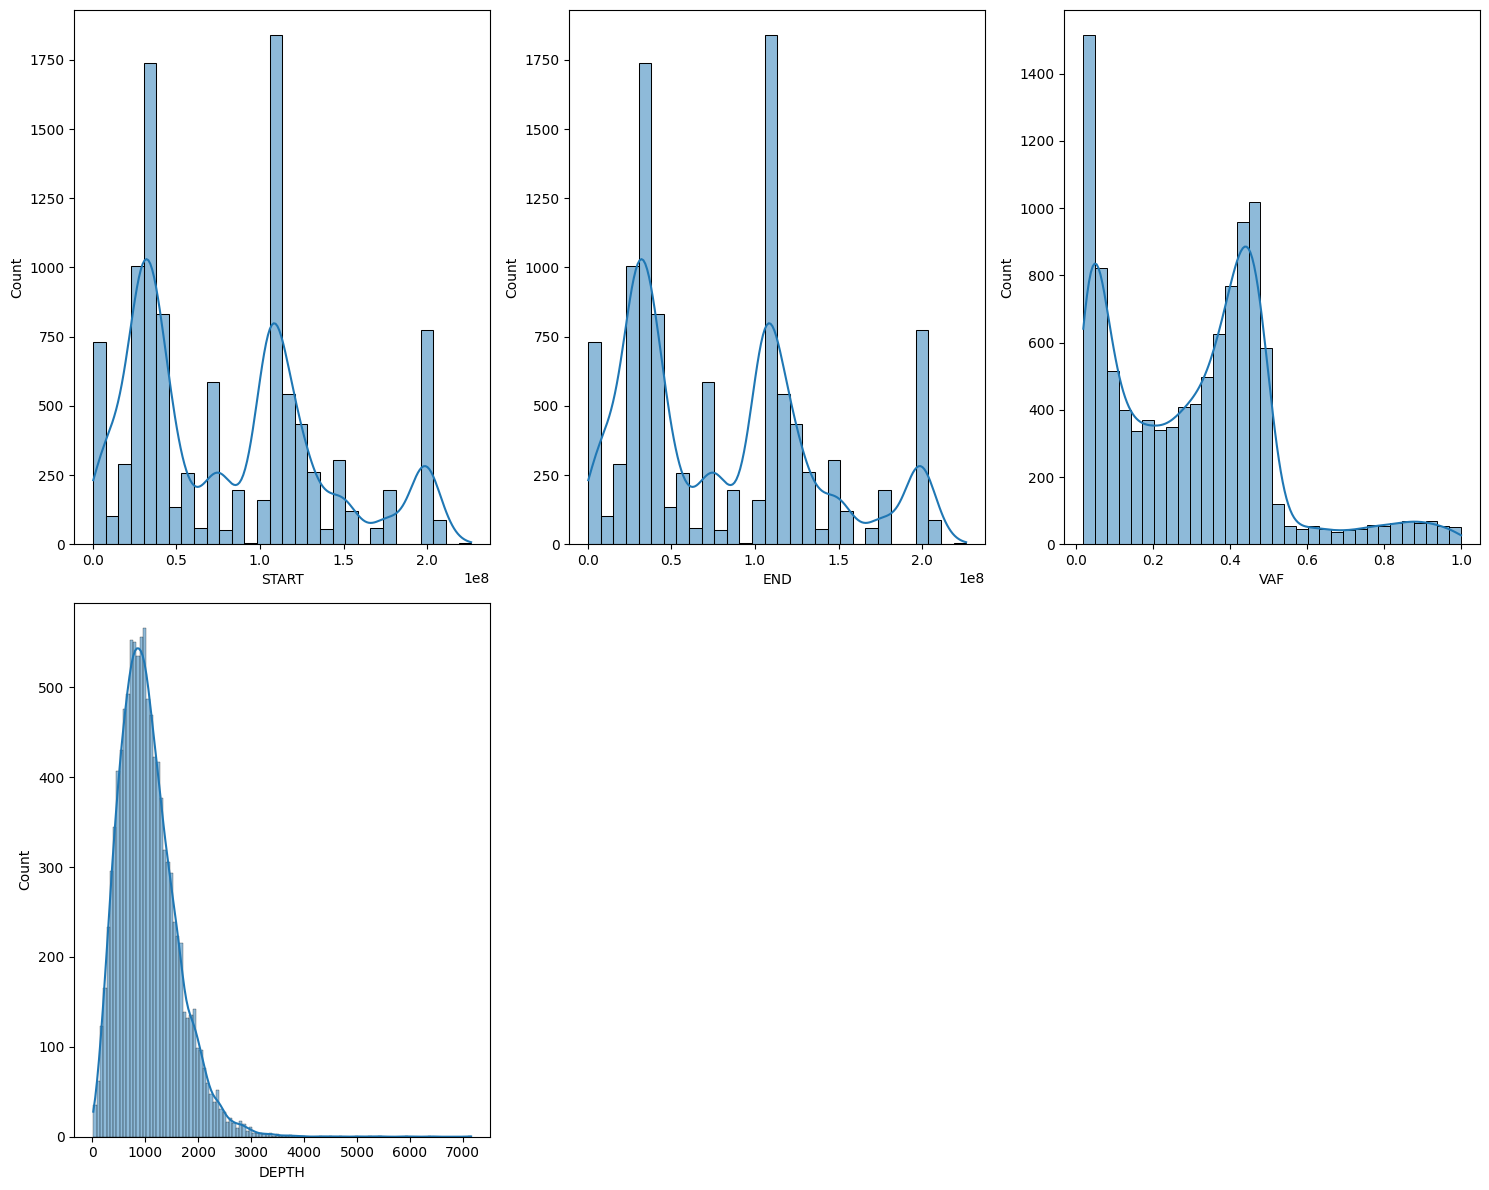

In [12]:
import math

col_int = [col for (col , dtype) in zip(mol_df.columns,mol_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]


num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(col_int , 1):
    plt.subplot(num_rows,3,i)
    sns.histplot(data = mol_df,x = cols,kde = True)
plt.tight_layout()
plt.show()

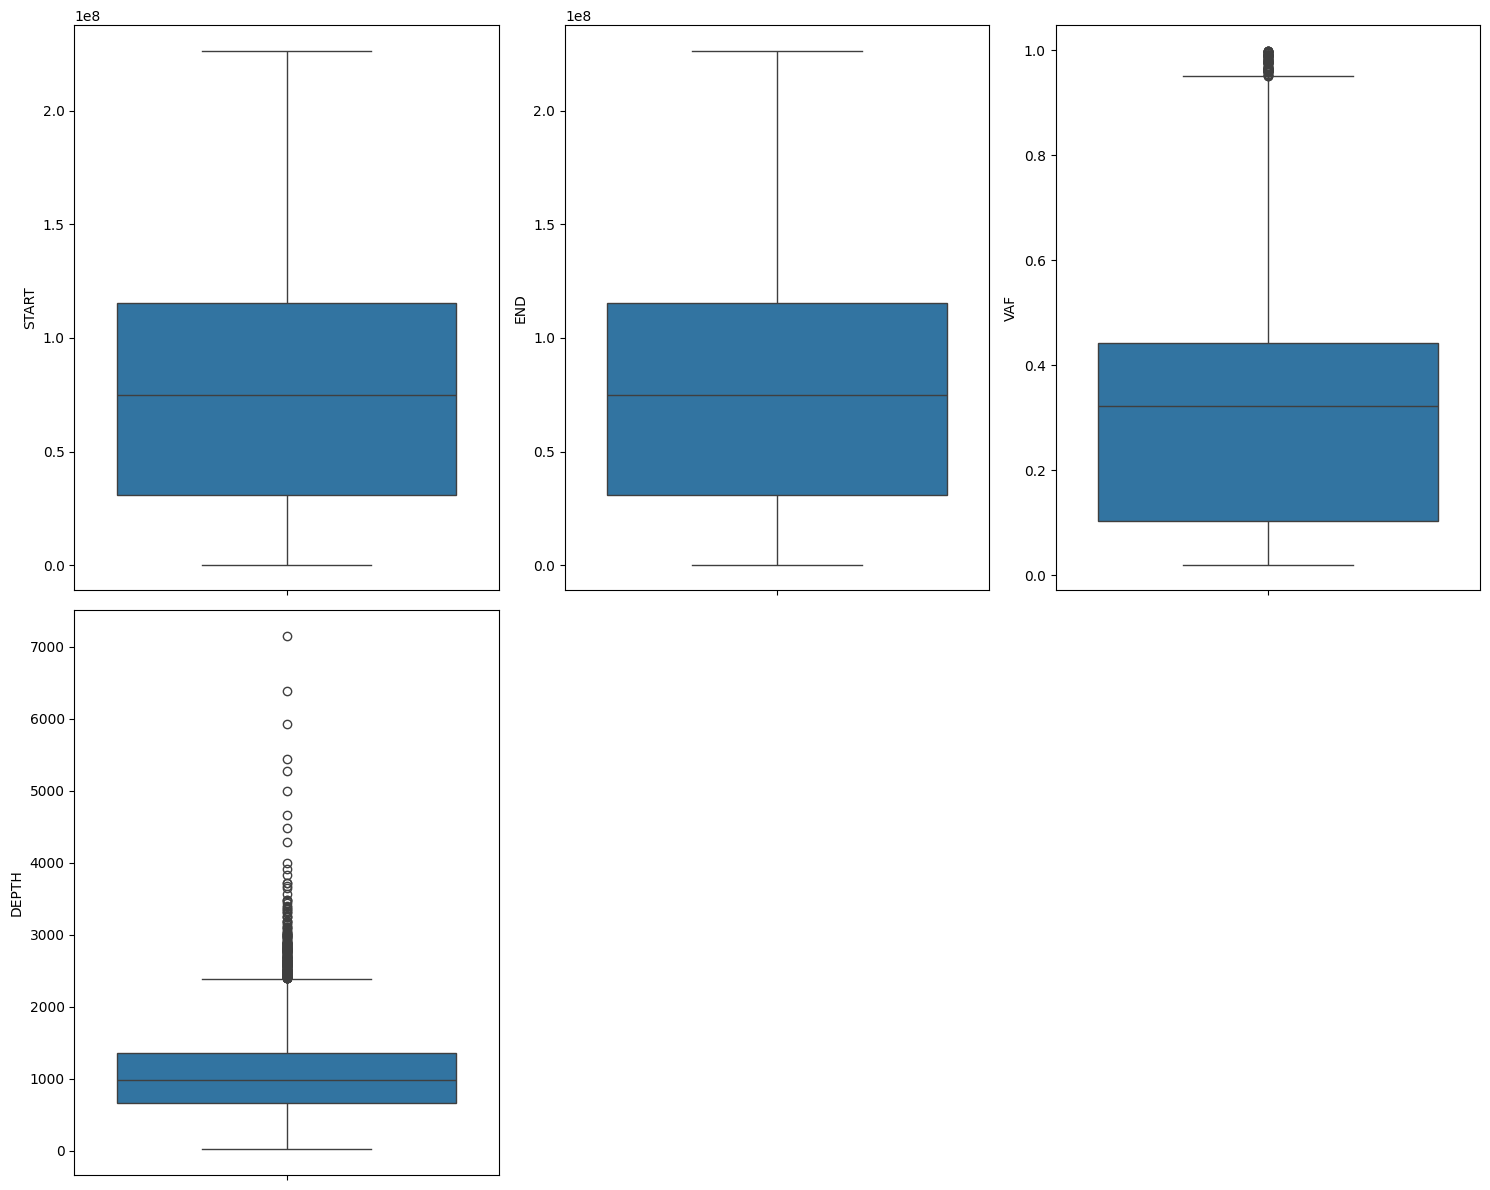

In [13]:
import math

col_int = [col for (col , dtype) in zip(mol_df.columns,mol_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]


num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(col_int , 1):
    plt.subplot(num_rows,3,i)
    sns.boxplot(data = mol_df , y=cols)
plt.tight_layout()
plt.show()

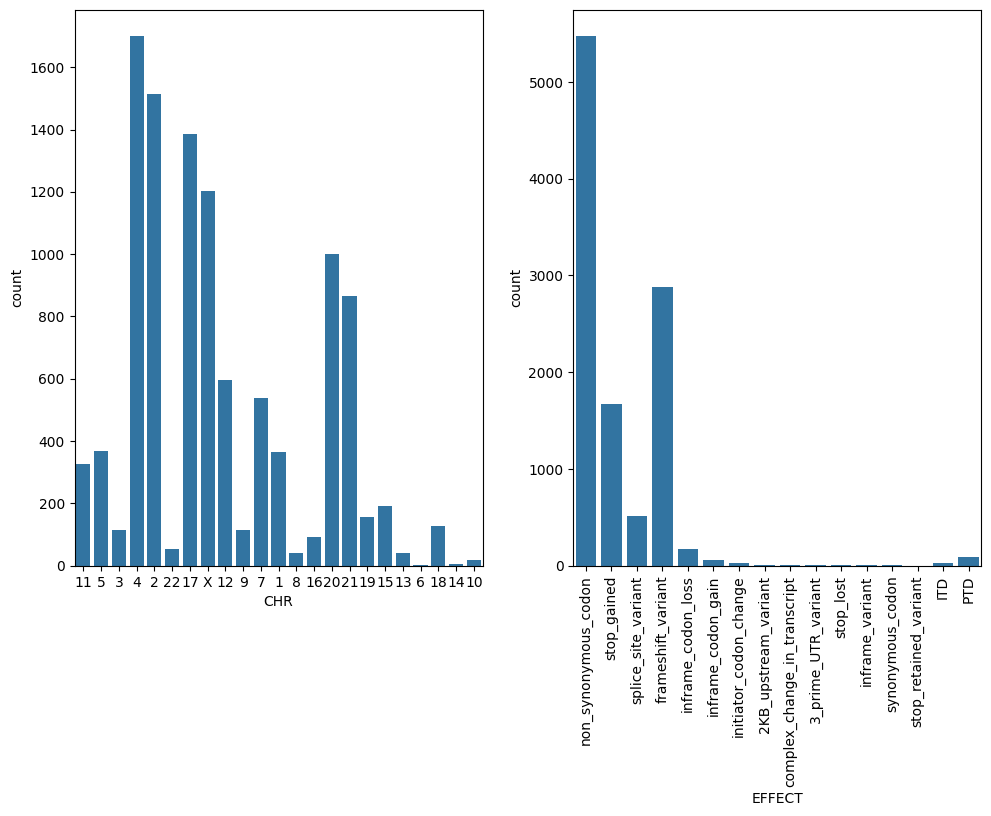

In [14]:
import math

categorical_col = ["CHR" , "EFFECT"]

num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(categorical_col , 1):
    plt.subplot(num_rows,3,i)
    sns.countplot(data = mol_df , x=cols)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [97]:
# GENE


print(mol_df["REF"].value_counts().top_k(k=5 , by="count"))


shape: (5, 2)
┌─────┬───────┐
│ REF ┆ count │
│ --- ┆ ---   │
│ str ┆ u32   │
╞═════╪═══════╡
│ C   ┆ 3199  │
│ G   ┆ 2965  │
│ T   ┆ 1771  │
│ A   ┆ 1234  │
│ TC  ┆ 123   │
└─────┴───────┘


# Bivariate Analysis

# Pearson coefficient

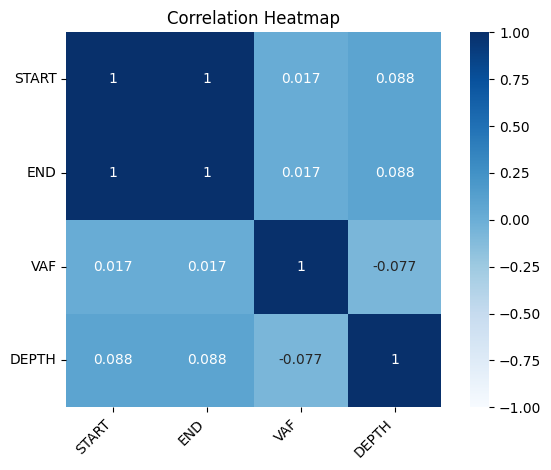

In [132]:
from scipy.stats import pearsonr


int_col = [col for (col,dtype) in zip(mol_df.columns , mol_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]

mol_int = mol_df.select(int_col)
            
mol_int = mol_int.drop_nulls()           

matrix = mol_int.corr()

axis_corr = sns.heatmap(
matrix,
vmin=-1, vmax=1, center=0,
cmap="Blues",
annot=True,
square=True,
xticklabels=matrix.columns,
yticklabels=matrix.columns
)


plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# Linear Relationship graph

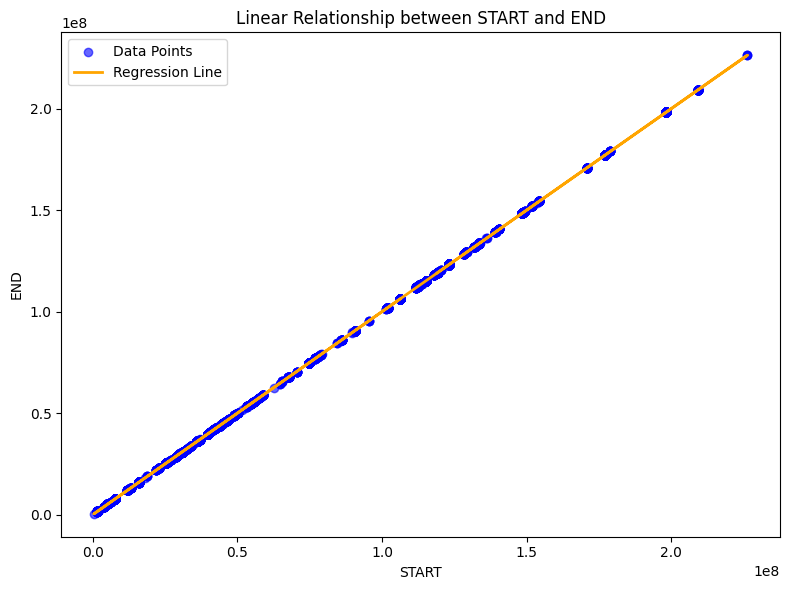

In [145]:
x = mol_int["START"]
y = mol_int["END"]

# Droite de régression (moindre carrés)
slope, intercept = np.polyfit(x, y, deg=1)
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c='blue', alpha=0.6, label="Data Points")  # Scatter en bleu
plt.plot(x, line, color='orange', linewidth=2, label="Regression Line")  # Droite orange

# Labels et titre
plt.xlabel("START")
plt.ylabel("END")
plt.title("Linear Relationship between START and END")
plt.legend()
plt.tight_layout()
plt.show()

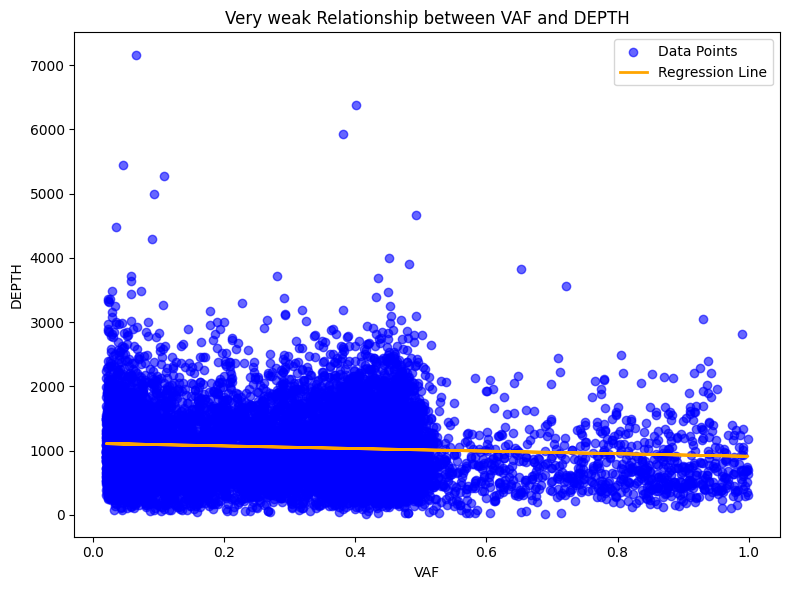

In [147]:
x = mol_int["VAF"]
y = mol_int["DEPTH"]

# Droite de régression (moindre carrés)
slope, intercept = np.polyfit(x, y, deg=1)
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c='blue', alpha=0.6, label="Data Points")  # Scatter en bleu
plt.plot(x, line, color='orange', linewidth=2, label="Regression Line")  # Droite orange

# Labels et titre
plt.xlabel("VAF")
plt.ylabel("DEPTH")
plt.title("Very weak Relationship between VAF and DEPTH")
plt.legend()
plt.tight_layout()
plt.show()

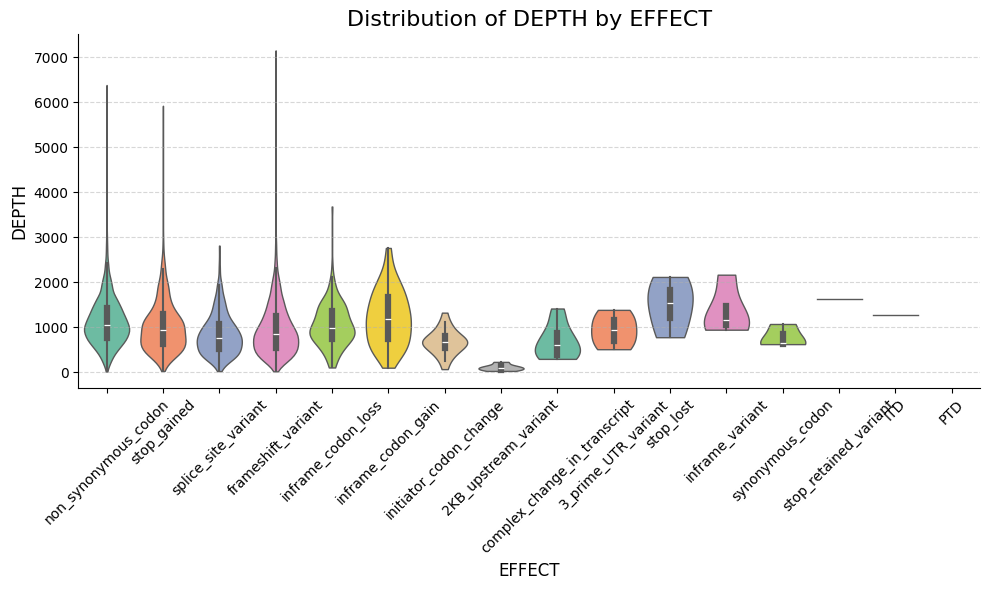

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.violinplot(
    x="EFFECT",
    y="DEPTH",
    data=mol_df,
    hue="EFFECT",              # Optional if EFFECT is already x-axis
    palette="Set2",            # Softer, aesthetically pleasing colors
    saturation=0.85,
    cut=0,                     # Prevents extrapolation beyond data range
    linewidth=1
)

# Clean legend if hue = x
plt.legend([], [], frameon=False)

# Titles and labels
plt.title("Distribution of DEPTH by EFFECT", fontsize=16)
plt.xlabel("EFFECT", fontsize=12)
plt.ylabel("DEPTH", fontsize=12)

# Style and layout
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()


C:\Users\zakar\AppData\Local\Temp\ipykernel_11104\897496229.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\zakar\AppData\Local\Temp\ipykernel_11104\897496229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


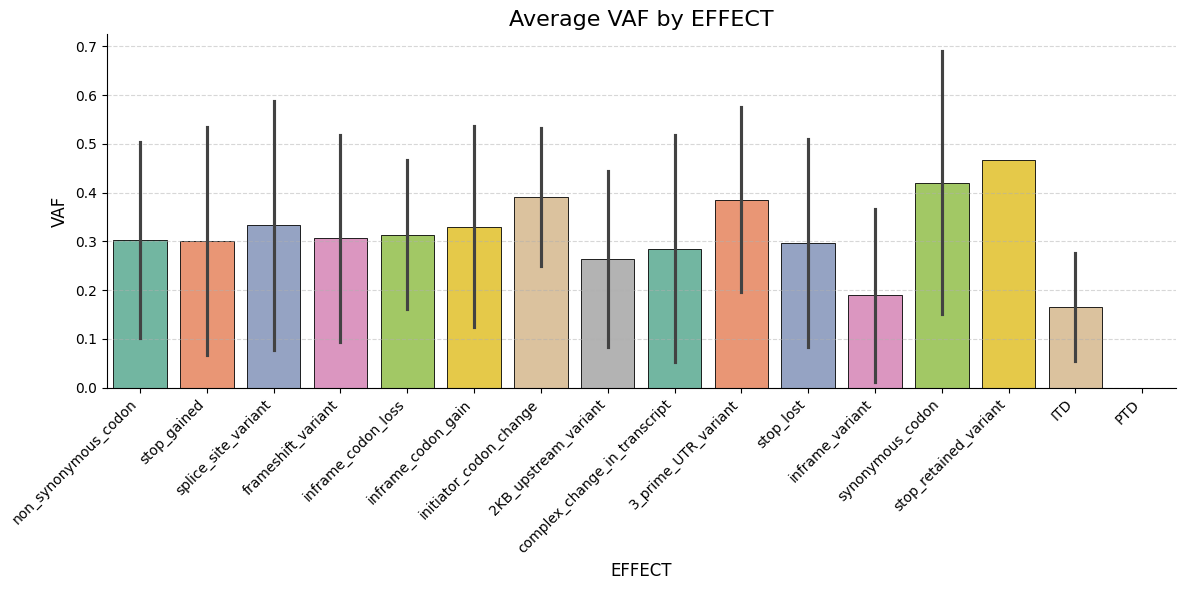

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.barplot(
    x="EFFECT",
    y="VAF",
    data=mol_df,
    palette="Set2",      # Pleasant color palette
    ci="sd",             # Show standard deviation as error bars
    edgecolor="black",
    linewidth=0.6
)

# Titles and labels
plt.title("Average VAF by EFFECT", fontsize=16)
plt.xlabel("EFFECT", fontsize=12)
plt.ylabel("VAF", fontsize=12)

# Aesthetic tweaks
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()


In [187]:
pd_mol = mol_df.to_pandas()

crosstab = pd.crosstab(pd_mol.EFFECT , pd_mol.GENE)

crosstab

GENE,ABL1,ARID1A,ARID2,ASXL1,ASXL2,ATRX,BAP1,BCL10,BCOR,BCORL1,...,TET2,TP53,U2AF1,U2AF2,WHSC1,WT1,ZBTB33,ZMYM3,ZNF318,ZRSR2
EFFECT,,,,,,,,,,,,,,,,,,,,,
2KB_upstream_variant,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3_prime_UTR_variant,0,0,0,0,0,0,0,0,0,0,...,5,0,0,0,0,0,0,0,0,0
ITD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
complex_change_in_transcript,0,0,0,0,0,0,0,0,1,0,...,3,0,0,0,0,0,0,0,0,0
frameshift_variant,0,3,14,716,21,6,0,0,113,21,...,685,44,0,1,0,35,14,3,0,53
inframe_codon_gain,0,1,0,0,0,0,0,0,0,0,...,4,2,11,0,0,0,0,0,0,1
inframe_codon_loss,0,0,0,0,0,0,0,0,0,0,...,21,9,0,24,0,0,0,0,0,1
inframe_variant,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0


In [ ]:
plt.subplot()

In [82]:
import re

mol_df = process_molecular_data(mol_df)

mol_df

C:\Users\zakar\AppData\Local\Temp\ipykernel_12476\2284950006.py:39: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(
C:\Users\zakar\AppData\Local\Temp\ipykernel_12476\364411870.py:41: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(


ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,has_['PTD'],has_['initiator_codon_change'],has_['stop_lost'],has_['ITD'],has_['complex_change_in_transcript'],has_['stop_retained_variant'],has_['2KB_upstream_variant'],has_['non_synonymous_codon'],has_['splice_site_variant'],has_['inframe_codon_gain'],has_['inframe_variant'],has_['frameshift_variant'],has_['synonymous_codon'],has_['inframe_codon_loss'],has_['stop_gained'],has_['3_prime_UTR_variant'],has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel
str,f64,f64,f64,str,str,str,str,i64,i64,i64,i64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,i64,i64,i64,i64,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i8,i8,i8
"""P100000""",11.0,0.525794,0.525794,"""G""","""A""","""CBL""","""p.C419Y""",0,0,0,1,0.083,0.543657,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.136582,0.209845,0.0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0
"""P100000""",5.0,0.581905,0.581905,"""G""","""T""","""IRF1""","""p.Y164*""",0,0,1,0,0.022,0.217126,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.012635,0.003886,0.0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0
"""P100000""",3.0,0.342248,0.342248,"""G""","""C""","""ROBO2""","""p.?""",0,0,1,1,0.41,0.361877,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.009627,0.002591,0.004132,0,0,0,1,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0
"""P100000""",4.0,0.468305,0.468305,"""G""","""T""","""TET2""","""p.R1262L""",0,0,0,1,0.43,0.340837,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1.0,0.53886,0.006198,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
"""P100000""",2.0,0.111014,0.111014,"""ACGAAGAGGGGGTGTTC""","""A""","""DNMT3A""","""p.E505fs*141""",0,1,0,0,0.0898,0.389649,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.362816,0.119171,0.0,0,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P131472""",3.0,0.348803,0.348803,null,null,"""KMT2A""","""MLL_PTD""",1,1,1,1,0.099793,0.419525,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.05716,0.11399,0.233471,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P131505""",3.0,0.348803,0.348803,null,null,"""KMT2A""","""MLL_PTD""",1,1,1,1,0.099793,0.419525,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.05716,0.11399,0.233471,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P131816""",3.0,0.348803,0.348803,null,null,"""KMT2A""","""MLL_PTD""",1,1,1,1,0.099793,0.419525,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.05716,0.11399,0.233471,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [85]:
chr_agg = colAgg(mol_df,["CHR" , "mutations_per_gene" , "mutations_per_gene_effect" , "mutations_per_region"])

chr_agg

ID,CHR_mean,CHR_max,CHR_min,mutations_per_gene_mean,mutations_per_gene_max,mutations_per_gene_min,mutations_per_gene_effect_mean,mutations_per_gene_effect_max,mutations_per_gene_effect_min,mutations_per_region_mean,mutations_per_region_max,mutations_per_region_min
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P106095""",13.5,23.0,4.0,0.513237,1.0,0.026474,0.285622,0.53886,0.032383,0.002066,0.004132,0.0
"""P110889""",8.25,23.0,2.0,0.645758,1.0,0.117329,0.543394,1.0,0.054404,0.231921,0.880165,0.0
"""P117196""",18.25,23.0,7.0,0.243682,0.5716,0.026474,0.317358,0.926166,0.016839,0.191116,0.764463,0.0
"""P105510""",7.0,12.0,2.0,0.243682,0.465704,0.021661,0.504534,1.0,0.009067,0.440083,0.880165,0.0
"""P116706""",8.333333,17.0,4.0,0.78219,1.0,0.34657,0.603195,0.648964,0.580311,0.349862,1.0,0.008264
…,…,…,…,…,…,…,…,…,…,…,…,…
"""P118199""",21.75,23.0,20.0,0.274368,0.5716,0.127557,0.391516,0.926166,0.073834,0.253099,0.764463,0.0
"""P121022""",16.857143,23.0,3.0,0.162197,0.5716,0.018051,0.23057,0.926166,0.020725,0.172078,0.764463,0.0
"""P116674""",10.5,20.0,1.0,0.306859,0.5716,0.042118,0.463083,0.926166,0.0,0.115702,0.231405,0.0


In [ ]:
lst = [
    "is_frameshift",
    "is_non_sens_mutation",
    "IS_MISSENSE",
    "complex_nucleotide_REF",
    "complex_nucleotide_ALT",
    "is_transition",
    "is_transversion",
    "is_indel"
]


mol_effect_2 = mol_df.group_by("ID").agg([
    pl.col(f"{col}").max().alias(f"has_{col}") for col in lst
])


In [92]:
mol_effect_2

ID,has_is_frameshift,has_is_non_sens_mutation,has_IS_MISSENSE,has_complex_nucleotide_REF,has_complex_nucleotide_ALT,has_is_transition,has_is_transversion,has_is_indel
str,i32,i32,i32,i32,i32,i8,i8,i8
"""P122427""",1,1,1,1,1,1,1,1
"""P116409""",1,1,1,0,1,0,1,1
"""P121824""",1,1,1,1,0,1,1,1
"""P120893""",1,1,0,1,0,0,0,1
"""P118243""",1,1,1,1,1,1,0,1
…,…,…,…,…,…,…,…,…
"""P100038""",1,1,1,0,1,1,0,1
"""P110924""",0,0,1,0,0,1,0,0
"""P105585""",0,0,1,0,0,0,1,0


In [94]:
full_df = full_df.join(mol_effect_2 , on="ID" , how="inner").join(chr_agg , on="ID" , how="inner")

In [95]:
full_df

ID,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost,has_is_frameshift,has_is_non_sens_mutation,has_IS_MISSENSE,has_complex_nucleotide_REF,has_complex_nucleotide_ALT,has_is_transition,has_is_transversion,has_is_indel,CHR_mean,CHR_max,CHR_min,mutations_per_gene_mean,mutations_per_gene_max,mutations_per_gene_min,mutations_per_gene_effect_mean,mutations_per_gene_effect_max,mutations_per_gene_effect_min,mutations_per_region_mean,mutations_per_region_max,mutations_per_region_min
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i8,i8,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P106095""",2,0.2135,0.391,0.036,1049.0,1332.0,766.0,1.1278e8,1.19388864e8,1.06164013e8,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,13.5,23.0,4.0,0.513237,1.0,0.026474,0.285622,0.53886,0.032383,0.002066,0.004132,0.0
"""P110889""",4,0.2605,0.465,0.024,491.5,671.0,179.0,1.0661e8,1.98266834e8,1.5836766e7,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,8.25,23.0,2.0,0.645758,1.0,0.117329,0.543394,1.0,0.054404,0.231921,0.880165,0.0
"""P117196""",4,0.308475,0.4655,0.0355,351.0,612.0,198.0,1.0553e8,1.48507475e8,3.1022441e7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,1,0,1,18.25,23.0,7.0,0.243682,0.5716,0.026474,0.317358,0.926166,0.016839,0.191116,0.764463,0.0
"""P105510""",2,0.1985,0.287,0.11,1934.0,2185.0,1683.0,1.22276268e8,1.98266834e8,4.6285702e7,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,7.0,12.0,2.0,0.243682,0.465704,0.021661,0.504534,1.0,0.009067,0.440083,0.880165,0.0
"""P116706""",3,0.475333,0.483,0.468,743.666667,967.0,619.0,9.5694e7,1.06193778e8,7.4732959e7,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,8.333333,17.0,4.0,0.78219,1.0,0.34657,0.603195,0.648964,0.580311,0.349862,1.0,0.008264
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P118199""",4,0.21315,0.286,0.1376,838.75,1552.0,482.0,5.9666348e7,1.23197044e8,3.1022441e7,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,1,0,1,21.75,23.0,20.0,0.274368,0.5716,0.127557,0.391516,0.926166,0.073834,0.253099,0.764463,0.0
"""P121022""",7,0.192271,0.413,0.028,890.142857,1369.0,510.0,6.1713e7,1.28200691e8,3.78124e6,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,0,1,1,1,0,1,1,1,1,16.857143,23.0,3.0,0.162197,0.5716,0.018051,0.23057,0.926166,0.020725,0.172078,0.764463,0.0
"""P116674""",2,0.4896,0.5379,0.4413,648.5,901.0,396.0,3.7414269e7,4.3806136e7,3.1022402e7,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,1,10.5,20.0,1.0,0.306859,0.5716,0.042118,0.463083,0.926166,0.0,0.115702,0.231405,0.0


In [96]:
pre_processed_mol = full_df.write_csv("../data/processed/X_train/molecular_train_preprocess_v2.csv")

In [56]:

col_to_drop = [col for col,dtype in zip(mol_df.columns,mol_df.dtypes) if dtype == pl.Utf8]

col_to_drop.remove("ID")

mol_df = mol_df.drop(col_to_drop)


In [59]:
mol_df = mol_df.drop("END")

In [81]:
mol_df

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH,has_['PTD'],has_['initiator_codon_change'],has_['stop_lost'],has_['ITD'],has_['complex_change_in_transcript'],has_['stop_retained_variant'],has_['2KB_upstream_variant'],has_['non_synonymous_codon'],has_['splice_site_variant'],has_['inframe_codon_gain'],has_['inframe_variant'],has_['frameshift_variant'],has_['synonymous_codon'],has_['inframe_codon_loss'],has_['stop_gained'],has_['3_prime_UTR_variant'],has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost
str,str,f64,f64,str,str,str,str,str,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""P100000""","""11""",1.19149248e8,1.19149248e8,"""G""","""A""","""CBL""","""p.C419Y""","""non_synonymous_codon""",0.083,1308.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P100000""","""5""",1.31822301e8,1.31822301e8,"""G""","""T""","""IRF1""","""p.Y164*""","""stop_gained""",0.022,532.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
"""P100000""","""3""",7.769406e7,7.769406e7,"""G""","""C""","""ROBO2""","""p.?""","""splice_site_variant""",0.41,876.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
"""P100000""","""4""",1.06164917e8,1.06164917e8,"""G""","""T""","""TET2""","""p.R1262L""","""non_synonymous_codon""",0.43,826.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P100000""","""2""",2.5468147e7,2.5468163e7,"""ACGAAGAGGGGGTGTTC""","""A""","""DNMT3A""","""p.E505fs*141""","""frameshift_variant""",0.0898,942.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P131472""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
"""P131505""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
"""P131816""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [58]:
mol_agg

ID,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,END_mean,END_max,END_min
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P110676""",0.262,0.262,0.262,1448.0,1448.0,1448.0,1.98266834e8,1.98266834e8,1.98266834e8,1.98266834e8,1.98266834e8,1.98266834e8
"""P122446""",0.533233,0.698,0.4337,1395.666667,1752.0,881.0,4.0450e7,1.06197552e8,7.574003e6,4.0450e7,1.06197552e8,7.574003e6
"""P120896""",0.039,0.039,0.039,1584.0,1584.0,1584.0,1.06157053e8,1.06157053e8,1.06157053e8,1.06157053e8,1.06157053e8,1.06157053e8
"""P116398""",0.341,0.341,0.341,908.0,908.0,908.0,1.98266611e8,1.98266611e8,1.98266611e8,1.98266611e8,1.98266611e8,1.98266611e8
"""P100415""",0.642333,0.984,0.46,549.333333,722.0,285.0,7.2389e7,1.06180841e8,3.6253012e7,7.2389e7,1.06180841e8,3.6253012e7
…,…,…,…,…,…,…,…,…,…,…,…,…
"""P116820""",0.311667,0.492,0.161,963.333333,1286.0,730.0,8.1648e7,1.70837543e8,2.5457242e7,8.1648167e7,1.70837547e8,2.5457242e7
"""P100146""",0.362186,0.9,0.0265,542.285714,736.0,208.0,1.00678468e8,1.48526867e8,1.5827442e7,1.0068e8,1.48526867e8,1.5827442e7
"""P121065""",0.200333,0.22,0.19,999.0,1235.0,774.0,3.0270e7,4.2531907e7,2.2811995e7,3.0270e7,4.2531907e7,2.2811995e7


# SAVING THE PREPROCESSED DATAFRAME

In [19]:
pre_processed_moleculaur = mol_df.write_csv("../data/processed/X_train/molecular_train_preprocess.csv")

# MOLECULAR TEST DATASET